In [2]:
import pandas as pd
import geopandas as gpd
import shapely
import numpy as np
import json
import os
from functools import partial
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

import nomad.io.base as loader
import nomad.stop_detection.utils as utils
import nomad.stop_detection.lachesis as LACHESIS
import nomad.stop_detection.dbscan as TADBSCAN
import nomad.stop_detection.grid_based as GRID_BASED # for oracle visits
import nomad.stop_detection.postprocessing as pp

import nomad.visit_attribution.visit_attribution as visits
import nomad.filters as filters
import nomad.city_gen as cg

from nomad.map_utils import blocks_to_mercator_gdf
from nomad.contact_estimation import compute_stop_detection_metrics

In [3]:
with open('config_2_stops.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

In [4]:
poi_table = gpd.read_parquet(config["buildings_file"]).rename(columns={"id":"location"})
sparse_df = loader.from_file(config["output_files"]["sparse_path"], format="parquet")
diaries_df = loader.from_file(config["output_files"]["diaries_path"], format="parquet").rename(
    columns={"identifier":"user_id"})

In [5]:
delta_roam_values = np.linspace(1, 50, 100)

config["algos"] = {
    **{f"lachesis_delta_{int(dr)}": {
        "func": LACHESIS.lachesis,
        "params": {
            'dt_max': 60,
            'delta_roam': dr
        }
    } for dr in delta_roam_values}
} 

In [6]:
results_list = []
for user in tqdm(diaries_df.user_id.unique(), desc='Processing users'):
    sparse = sparse_df.query("user_id==@user").copy()
    truth = diaries_df.query("user_id==@user").copy()
    
    # Run all Lachesis variations
    for algo_name, algo_config in config["algos"].items():
        # Run stop detection
        stops = algo_config["func"](sparse, **algo_config["params"], x="x", y="y", timestamp='timestamp')
        
        # Map stops to buildings
        stops["location"] = visits.point_in_polygon(
            stops, 
            poi_table=poi_table, 
            data_crs='EPSG:3857',
            max_distance=0.5, 
            location_id='location', 
            x='x', 
            y='y'
        )
        
        # Compute metrics
        metrics = compute_stop_detection_metrics(
            stops=stops,
            truth=truth,
            user_id=user,
            algorithm=algo_name,
            traj_cols={'location_id': 'location'},
            timestamp='timestamp'
        )
        
        # Add delta_roam value to metrics
        metrics['delta_roam'] = algo_config['params']['delta_roam']
        
        results_list.append(metrics)

# Convert to DataFrame
results_df = pd.DataFrame(results_list)

print(f"Computed metrics for {len(results_df)} user-algorithm combinations")

Processing users: 100%|██████████| 100/100 [05:23<00:00,  3.23s/it]

Computed metrics for 10000 user-algorithm combinations


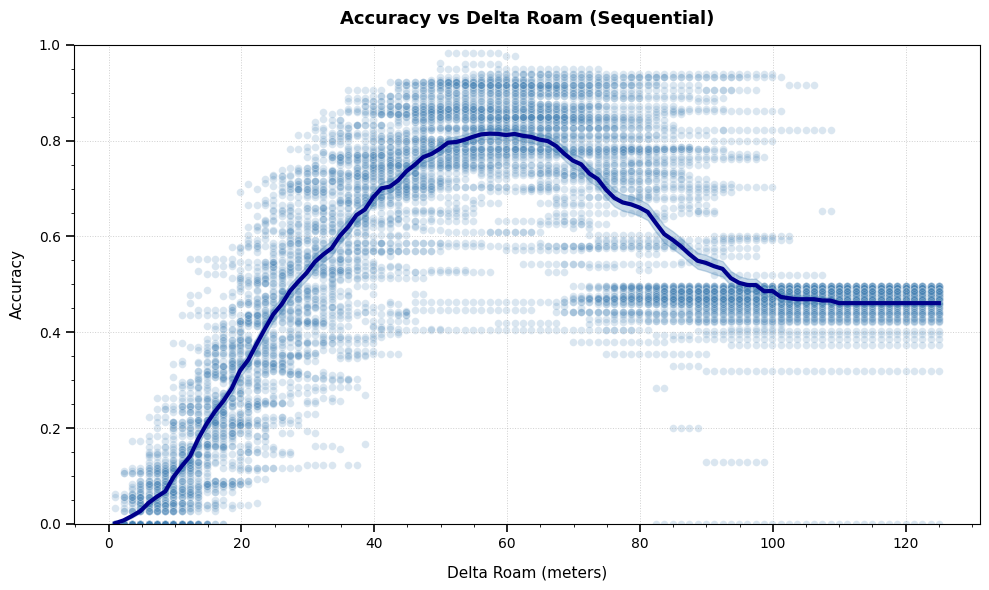

Number of unique delta_roam values: 100


In [7]:
# Plotting function adapted for delta_roam
def plot_metric_delta_roam(metric, title, save_path='figures'):
    """Plot a metric vs delta_roam for Lachesis."""
    chart_df = results_df.groupby(['delta_roam'])[metric].agg(['mean', 'sem']).reset_index()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Add scatter plot background (individual data points)
    sns.scatterplot(data=results_df, x='delta_roam', y=metric,
                   alpha=0.2, s=30, ax=ax, color='steelblue')
    
    # Add line plot (mean values)
    ax.plot(chart_df['delta_roam'], chart_df['mean'], 
            color='darkblue', linewidth=3, label='Mean')
    
    # Add confidence band (mean ± SEM)
    ax.fill_between(chart_df['delta_roam'], 
                    chart_df['mean'] - chart_df['sem'],
                    chart_df['mean'] + chart_df['sem'],
                    alpha=0.3, color='steelblue')
    
    # Styling
    ax.set_xlabel('Delta Roam (meters)', fontsize=11, labelpad=10)
    ax.set_ylabel(title, fontsize=11, labelpad=10)
    ax.set_ylim(0, 1)
    ax.set_title(f'{title} vs Delta Roam (Sequential)', fontsize=13, pad=15, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6, linewidth=0.7)
    ax.tick_params(axis='both', which='major', labelsize=10, length=6, width=1.2)
    ax.minorticks_on()
    
    plt.tight_layout()
    plt.savefig(f"{save_path}/lachesis_delta_roam_{metric}.svg", bbox_inches='tight')
    plt.savefig(f"{save_path}/lachesis_delta_roam_{metric}.png", dpi=600, bbox_inches='tight')
    plt.show(block=False)
    plt.close()

plot_metric_delta_roam('recall', 'Accuracy')

print(f"Number of unique delta_roam values: {results_df['delta_roam'].nunique()}")